<a href="https://colab.research.google.com/github/personallypetra/Grand_Challenge-/blob/Petra/PetraAccenture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!rm -rf Grand_Challenge
!git clone https://github.com/personallypetra/Grand_Challenge-.git
%cd Grand_Challenge-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine, inspect

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
import os
print(os.listdir("data_petra"))

['Export-DownloadCenterFile-20260307-205601.xlsx', 'Export-DownloadCenterFile-20260307-163501.xlsx', 'Export-DownloadCenterFile-20260307-205628.xlsx', 'Export-DownloadCenterFile-20260307-205608.xlsx', 'Export-DownloadCenterFile-20260307-205623.xlsx', 'Export-DownloadCenterFile-20260307-205618.xlsx', 'Export-DownloadCenterFile-20260307-162932.xlsx', 'Export-DownloadCenterFile-20260307-205613.xlsx', 'Export-DownloadCenterFile-20260307-163528.xlsx']


In [3]:
%%capture
df1 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-205601.xlsx")
df2 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-205608.xlsx")
df3 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-205613.xlsx")
df4 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-205618.xlsx")
df5 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-205623.xlsx")
df6 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-205628.xlsx")

In [4]:
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index  = True)
df.to_excel("Total_Load_Full.xlsx", index = False)
df.head()

,Date,Total Load [MW],Forecast Total Load [MW],Bidding Zone
0,2026-03-06 23:45:00,700.942,692.646,Calabria
1,2026-03-06 23:45:00,2157.437,2131.902,Centre-North
2,2026-03-06 23:45:00,5216.721,5154.979,Centre-South
3,2026-03-06 23:45:00,18011.345,17798.173,North
4,2026-03-06 23:45:00,760.850,751.845,Sardinia


The available database measures total load and forecast Total Load each 15 minutes. We are now creating new database that is going to contain same informations on daily basis.

In [5]:
df = df[~df["Date"].astype(str).str.contains("Applied filters", na = False)]
df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
df["Date"] = df["Date"].dt.floor("D")

TotalLoadDaily = df.groupby(["Date", "Bidding Zone"], as_index = False).agg(
    {"Total Load [MW]":"sum",
     "Forecast Total Load [MW]": "sum"
                                                                             })
TotalLoadDaily.to_excel("Total_Load_Daily.xlsx", index = False)
TotalLoadDaily.head(9)


,Date,Bidding Zone,Total Load [MW],Forecast Total Load [MW]
0,2021-03-01,Calabria,64020.862,63488.833
1,2021-03-01,Centre-North,283967.215,281751.575
2,2021-03-01,Centre-South,576870.367,572046.452
3,2021-03-01,Italy,3510784.002,3479473.005
4,2021-03-01,North,2031942.282,2013133.832
5,2021-03-01,Sardinia,95270.554,94358.747
6,2021-03-01,Sicily,206078.953,204352.898
7,2021-03-01,South,252633.769,250340.668
8,2021-03-02,Calabria,63032.749,63038.980


In [6]:
TotalLoadDaily["Bidding Zone"].unique()

array(['Calabria', 'Centre-North', 'Centre-South', 'Italy', 'North',
       'Sardinia', 'Sicily', 'South'], dtype=object)

In [7]:
print(TotalLoadDaily["Date"].head(1))
print(TotalLoadDaily["Date"].iloc[-1])

0   2021-03-01
Name: Date, dtype: datetime64[ns]
2026-03-06 00:00:00


Now we have one database "TotalLoadDaily" that contains both predicted and actual total usage of electricity grouped by regions from 1st March 2021 till 6th March 2026. Moreover, we have a daily usage for the whole Italy.

In [13]:
%%capture
df2 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-163528.xlsx")
df3 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-162932.xlsx")
df4 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260307-163501.xlsx")


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [14]:
df = pd.concat([df2, df3, df4], ignore_index  = True)
df.to_excel("Energy_Production.xlsx", index = False)
df.head()

,Date,Actual Generation,Primary Source
0,2022-12-31 23:00:00,15.960,Thermal
1,2022-12-31 23:00:00,1.810,Hydro
2,2022-12-31 23:00:00,0.620,Geothermal
3,2022-12-31 23:00:00,0.000,Photovoltaic
4,2022-12-31 23:00:00,1.952,Self-consumption


In [15]:
df = df[~df["Date"].astype(str).str.contains("Applied filters", na = False)]
df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
df["Date"] = df["Date"].dt.floor("D")
TotalEnergyProduction = df.groupby(["Date", "Primary Source"], as_index = False).agg(
    {"Actual Generation":"sum"})
TotalEnergyProduction.to_excel("Energy_Production.xlsx", index = False)
TotalEnergyProduction.head(9)

,Date,Primary Source,Actual Generation
0,2022-01-01,Geothermal,15.480
1,2022-01-01,Hydro,75.060
2,2022-01-01,Photovoltaic,26.300
3,2022-01-01,Self-consumption,37.863
4,2022-01-01,Thermal,239.940
5,2022-01-01,Wind,47.070
6,2022-01-02,Geothermal,15.600
7,2022-01-02,Hydro,69.410
8,2022-01-02,Photovoltaic,22.980


In [18]:
print((TotalEnergyProduction["Primary Source"]).unique())

['Geothermal' 'Hydro' 'Photovoltaic' 'Self-consumption' 'Thermal' 'Wind']


In [16]:
print(TotalEnergyProduction["Date"].head(1))
print(TotalEnergyProduction["Date"].iloc[-1])

0   2022-01-01
Name: Date, dtype: datetime64[ns]
2026-03-06 00:00:00


We have date on a daily basis for the generated energy from Geotermal, Hydro, Pgotovoltaic, Self-Consumption, Thermal and Wind source from 1st January 2022 till 6th March 2026.

Since the data above covers the Lazio Region, in order to see how much of the consumed energy came from the previously mentioned sources, we are going to extract data from 'TotalDailyLoad' about 'Centre-South' region.


In [28]:
energy_plt = TotalEnergyProduction.pivot(index = "Date", columns = "Primary Source", values = "Actual Generation").reset_index()
energy_plt.columns.name = None
energy_plt["Total"] = energy_plt[["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]].sum(axis = 1)
energy_plt["Media"] = energy_plt[["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]].mean(axis = 1)


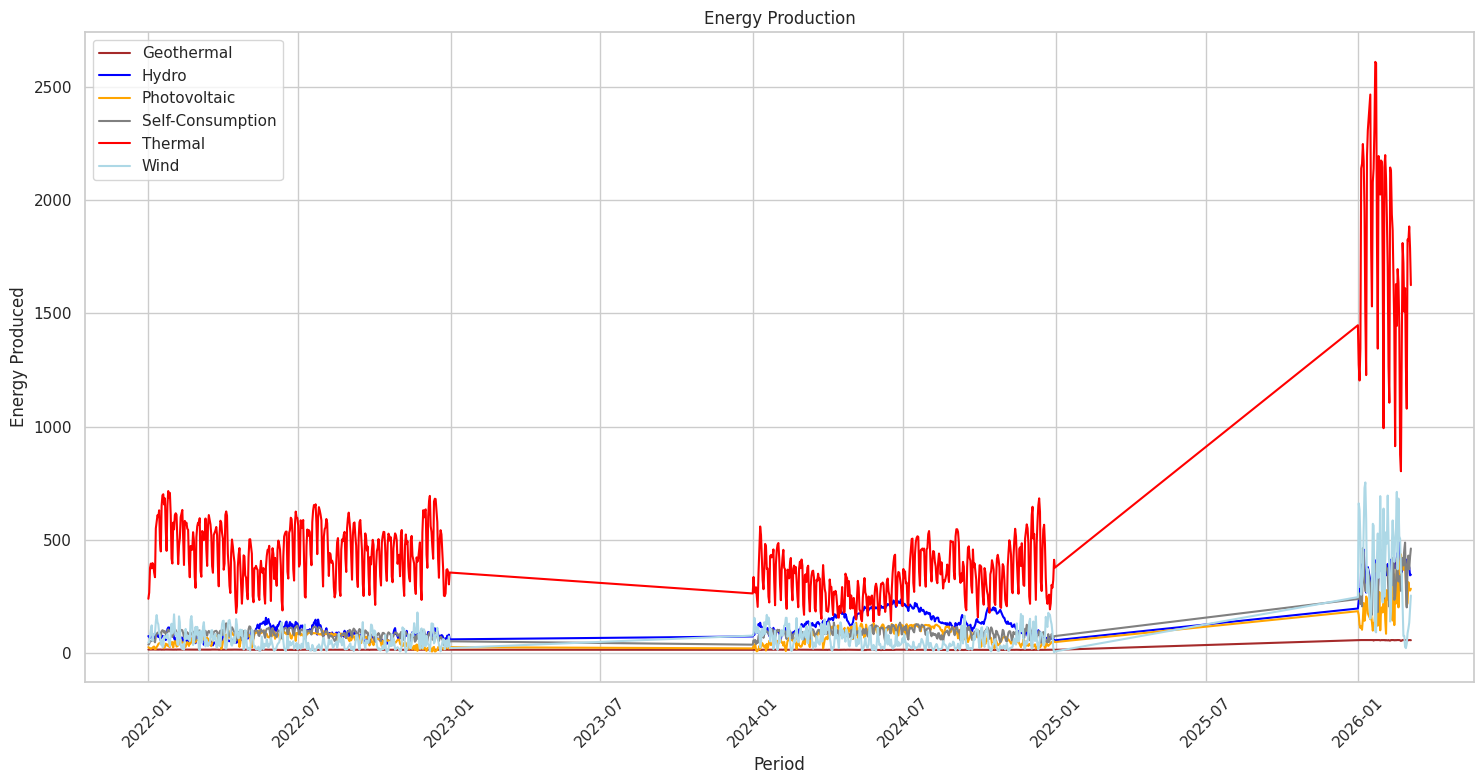

In [34]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
plt.figure(figsize = (15, 8))

plt.plot(energy_plt["Date"], energy_plt["Geothermal"], color = "brown", label = "Geothermal")
plt.plot(energy_plt["Date"], energy_plt["Hydro"], color = "blue", label = "Hydro")
plt.plot(energy_plt["Date"], energy_plt["Photovoltaic"], color = "orange", label = "Photovoltaic")
plt.plot(energy_plt["Date"], energy_plt["Self-consumption"], color = "grey", label = "Self-Consumption")
plt.plot(energy_plt["Date"], energy_plt["Thermal"], color = "red", label = "Thermal")
plt.plot(energy_plt["Date"], energy_plt["Wind"], color = "lightblue", label = "Wind")


plt.xlabel("Period")
plt.ylabel("Energy Produced")
plt.title("Energy Production")
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

there is clearly missing data in the years 2023 and 2025.
We are going to plot separately data that we have in 2022, 2024, and 2026.


---
### 2022


In [37]:
energy_subset2022 = energy_plt[
    (energy_plt["Date"] >= "2022-01-01") &
    (energy_plt["Date"] <= "2022-12-31")
]

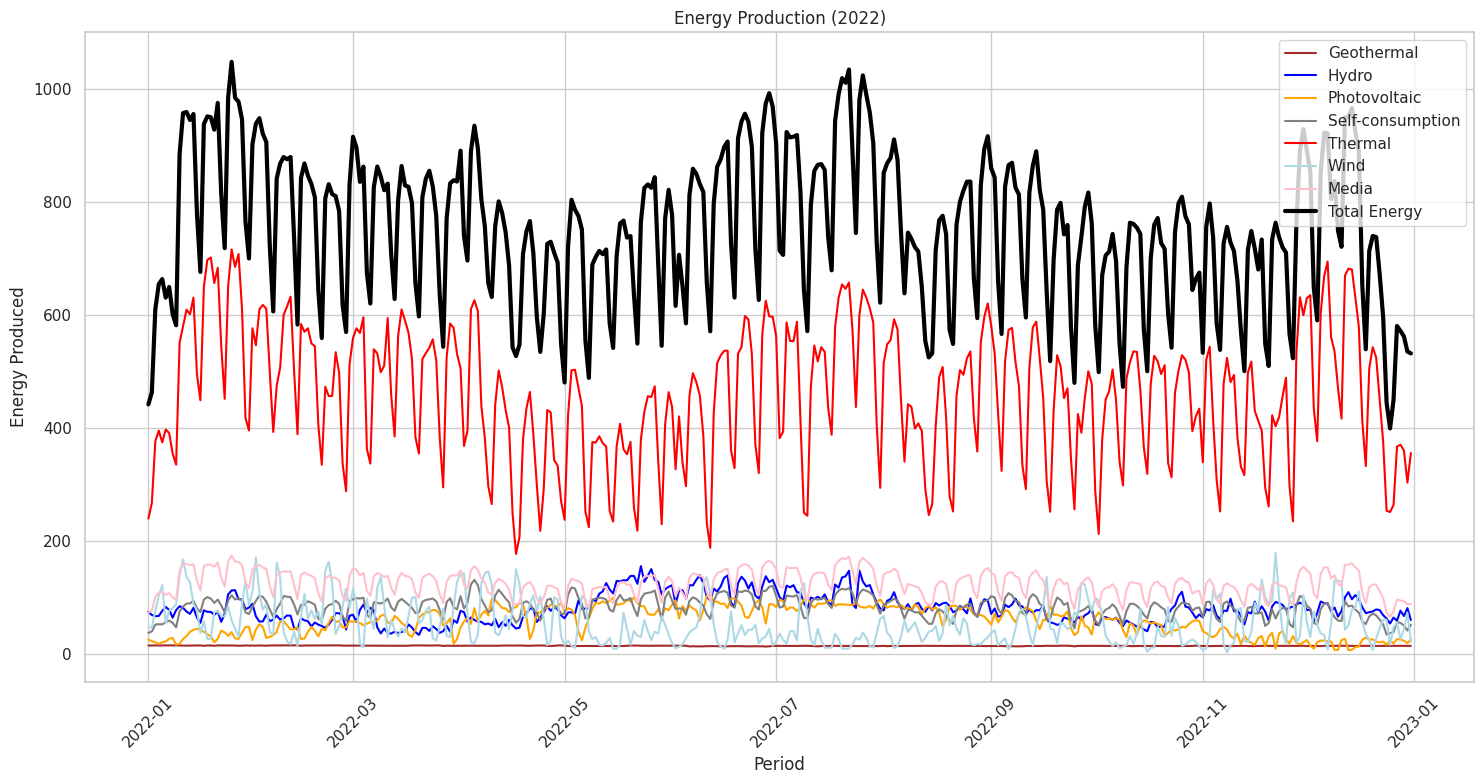

In [38]:
plt.figure(figsize=(15,8))

plt.plot(energy_subset2022["Date"], energy_subset2022["Geothermal"], color="brown", label="Geothermal")
plt.plot(energy_subset2022["Date"], energy_subset2022["Hydro"], color="blue", label="Hydro")
plt.plot(energy_subset2022["Date"], energy_subset2022["Photovoltaic"], color="orange", label="Photovoltaic")
plt.plot(energy_subset2022["Date"], energy_subset2022["Self-consumption"], color="grey", label="Self-consumption")
plt.plot(energy_subset2022["Date"], energy_subset2022["Thermal"], color="red", label="Thermal")
plt.plot(energy_subset2022["Date"], energy_subset2022["Wind"], color="lightblue", label="Wind")

plt.plot(energy_subset2022["Date"], energy_subset2022["Media"], color="pink", label="Media")
plt.plot(energy_subset2022["Date"], energy_subset2022["Total"], color="black", linewidth=3, label="Total Energy")

plt.xlabel("Period")
plt.ylabel("Energy Produced")
plt.title("Energy Production (2022)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2024

In [39]:
energy_subset2024 = energy_plt[
    (energy_plt["Date"] >= "2024-01-01") &
    (energy_plt["Date"] <= "2024-12-31")
]

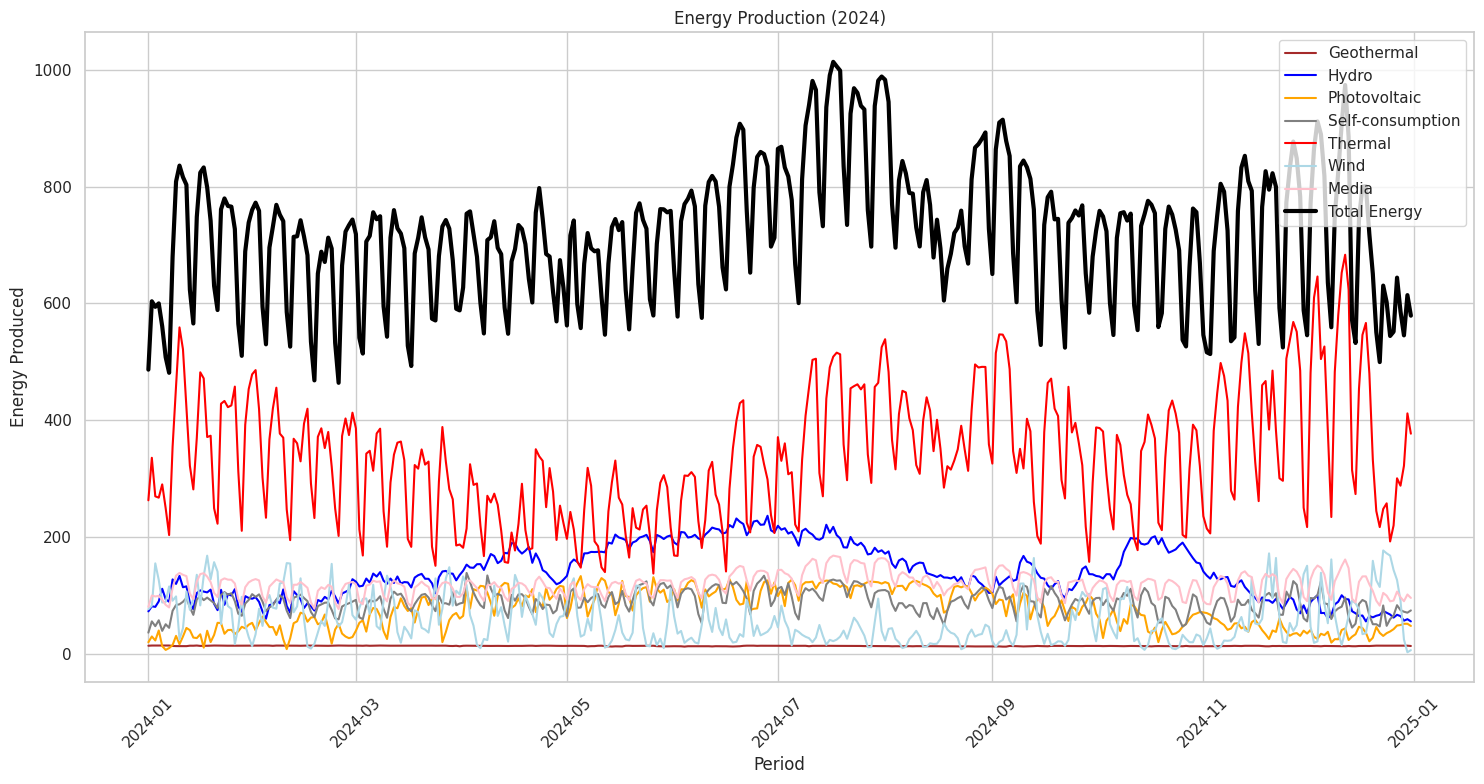

In [40]:
plt.figure(figsize=(15,8))

plt.plot(energy_subset2024["Date"], energy_subset2024["Geothermal"], color="brown", label="Geothermal")
plt.plot(energy_subset2024["Date"], energy_subset2024["Hydro"], color="blue", label="Hydro")
plt.plot(energy_subset2024["Date"], energy_subset2024["Photovoltaic"], color="orange", label="Photovoltaic")
plt.plot(energy_subset2024["Date"], energy_subset2024["Self-consumption"], color="grey", label="Self-consumption")
plt.plot(energy_subset2024["Date"], energy_subset2024["Thermal"], color="red", label="Thermal")
plt.plot(energy_subset2024["Date"], energy_subset2024["Wind"], color="lightblue", label="Wind")

plt.plot(energy_subset2024["Date"], energy_subset2024["Media"], color="pink", label="Media")
plt.plot(energy_subset2024["Date"], energy_subset2024["Total"], color="black", linewidth=3, label="Total Energy")

plt.xlabel("Period")
plt.ylabel("Energy Produced")
plt.title("Energy Production (2024)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2026

In [42]:
energy_subset2026 = energy_plt[
    (energy_plt["Date"] >= "2026-01-01") &
    (energy_plt["Date"] <= "2026-3-6")
]

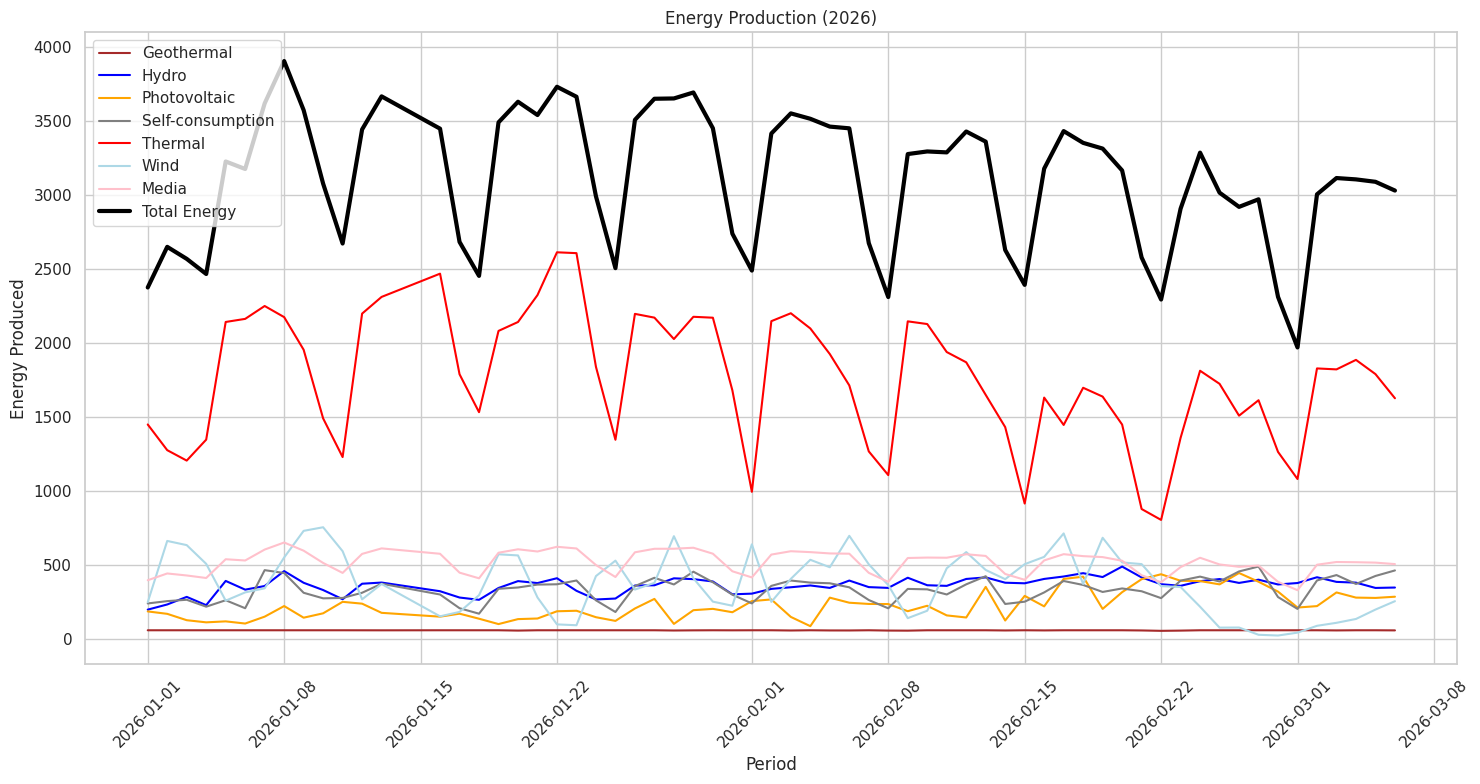

In [43]:
plt.figure(figsize=(15,8))

plt.plot(energy_subset2026["Date"], energy_subset2026["Geothermal"], color="brown", label="Geothermal")
plt.plot(energy_subset2026["Date"], energy_subset2026["Hydro"], color="blue", label="Hydro")
plt.plot(energy_subset2026["Date"], energy_subset2026["Photovoltaic"], color="orange", label="Photovoltaic")
plt.plot(energy_subset2026["Date"], energy_subset2026["Self-consumption"], color="grey", label="Self-consumption")
plt.plot(energy_subset2026["Date"], energy_subset2026["Thermal"], color="red", label="Thermal")
plt.plot(energy_subset2026["Date"], energy_subset2026["Wind"], color="lightblue", label="Wind")

plt.plot(energy_subset2026["Date"], energy_subset2026["Media"], color="pink", label="Media")
plt.plot(energy_subset2026["Date"], energy_subset2026["Total"], color="black", linewidth=3, label="Total Energy")

plt.xlabel("Period")
plt.ylabel("Energy Produced")
plt.title("Energy Production (2026)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()